# Multi-Asset ETF Risk Management & Stress Testing

This project translates the Financial Mathematics lecture on **Value at Risk and other risk measures** into a practical multi-asset risk-management case study.

**ETF universe**

- **SPY** — broad U.S. equities
- **SOXX** — semiconductors
- **XLE** — energy / oil equities
- **TLT** — long-duration U.S. Treasuries
- **GLD** — gold

All five instruments trade in the U.S. market, so the analysis uses one aligned trading calendar.

The workflow is:

$$
\text{Returns}
\rightarrow
\text{Loss Distribution}
\rightarrow
\text{VaR}
\rightarrow
\text{Expected Shortfall}
\rightarrow
\text{Historical / Parametric / Simulation Methods}
\rightarrow
\text{Stress Scenarios}
\rightarrow
\text{Limits of VaR}
$$

The purpose is **risk measurement**, not return forecasting.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy import stats
from scipy.stats import binom

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

TICKERS = ["SPY", "SOXX", "XLE", "TLT", "GLD"]
START = "2015-01-01"
END = "2026-09-13"

PORTFOLIO_VALUE = 100_000
WEIGHTS = pd.Series(0.20, index=TICKERS)

CONFIDENCE_LEVELS = [0.95, 0.99]

## 1. Losses and Value at Risk

Let $L$ denote portfolio loss.

For confidence level $\alpha$,

$$
\boxed{
VaR_\alpha(L)
=
\inf\{x\in\mathbb{R}:P(L>x)\le 1-\alpha\}
}
$$

and for a continuous loss distribution,

$$
\boxed{
VaR_\alpha(L)=F_L^{-1}(\alpha)
}
$$

so VaR is simply a **quantile of the loss distribution**.

Interpretation:

> $VaR_{95\%}=€5{,}000$ means that, under the model and horizon used, only about 5% of losses are expected to exceed €5,000.

VaR does **not** say how large the loss can become after that threshold is exceeded.

## 2. Market data and portfolio definition

We use a simple **equal-weight portfolio**:

$$
w_i=0.20,
\qquad
\sum_iw_i=1.
$$

The portfolio is deliberately diversified across different risk exposures rather than optimized for return.

For simple returns,

$$
R_{P,t}
=
w^\top R_t.
$$

If the portfolio value is $V_0$, daily P\&L is

$$
\Delta V_t
=
V_0R_{P,t}
$$

and loss is defined as

$$
\boxed{
L_t=-\Delta V_t
}.
$$

Positive $L_t$ therefore means a loss.

In [2]:
raw = yf.download(
    TICKERS,
    start=START,
    end=END,
    auto_adjust=True,
    progress=False,
)

if raw.empty:
    raise RuntimeError("No market data were downloaded.")

if isinstance(raw.columns, pd.MultiIndex):
    prices = raw["Close"].copy()
else:
    prices = raw.copy()

prices = prices[TICKERS].dropna(how="any")
returns = prices.pct_change().dropna()

portfolio_returns = returns @ WEIGHTS
portfolio_pnl = PORTFOLIO_VALUE * portfolio_returns
portfolio_losses = -portfolio_pnl

print("Observations:", len(returns))
print("Date range:", returns.index.min().date(), "to", returns.index.max().date())
prices.tail()

Observations: 2939
Date range: 2015-01-05 to 2026-09-11


Ticker,SPY,SOXX,XLE,TLT,GLD
Date,,,,,
2026-09-04,768.282227,519.520325,64.059998,82.209999,406.769989
2026-09-08,764.062683,528.054749,64.769997,82.199997,399.720001
2026-09-09,760.511536,531.652405,65.309998,81.730003,403.350006
2026-09-10,755.952820,517.091919,64.930000,80.779999,396.359985
2026-09-11,762.396790,526.725647,65.139999,80.870003,398.769989


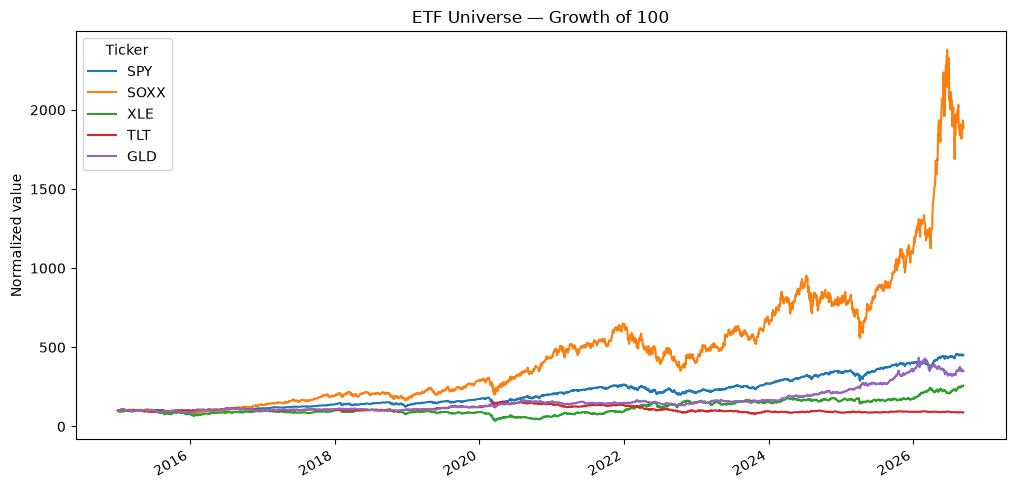

In [3]:
normalized = 100 * prices / prices.iloc[0]

ax = normalized.plot(
    figsize=(12, 6),
    title="ETF Universe — Growth of 100",
)
ax.set_ylabel("Normalized value")
ax.set_xlabel("")
plt.show()

## 3. Portfolio volatility and the role of correlation

For asset positions with weights $w$, covariance matrix $\Sigma$, and portfolio value $V_0$,

$$
\sigma_P^2
=
w^\top\Sigma w.
$$

For two assets this expands to

$$
\sigma_P^2
=
w_1^2\sigma_1^2
+
w_2^2\sigma_2^2
+
2w_1w_2\rho_{12}\sigma_1\sigma_2.
$$

This is why correlation matters directly for portfolio risk.

In [4]:
daily_cov = returns.cov()
daily_portfolio_vol = np.sqrt(
    WEIGHTS.values @ daily_cov.values @ WEIGHTS.values
)

pd.Series({
    "daily_portfolio_return_mean": portfolio_returns.mean(),
    "daily_portfolio_volatility": daily_portfolio_vol,
    "annualized_volatility": daily_portfolio_vol * np.sqrt(252),
}).to_frame("value")

,value
daily_portfolio_return_mean,0.000553
daily_portfolio_volatility,0.008846
annualized_volatility,0.140431


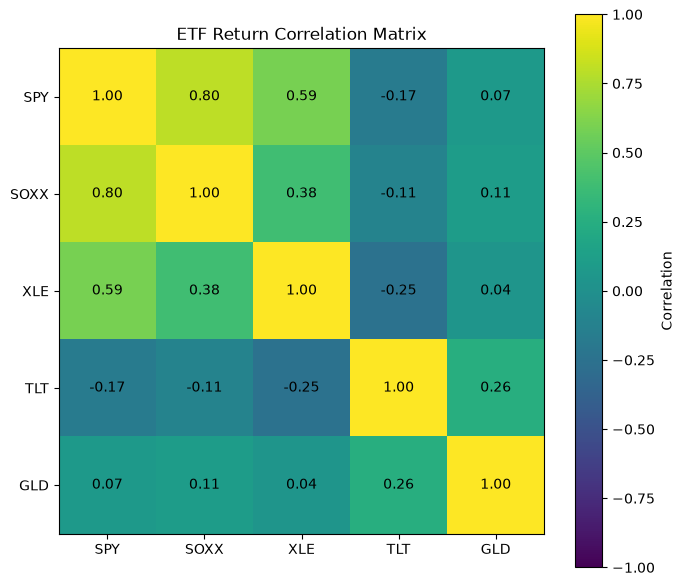

In [5]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1)

ax.set_xticks(range(len(TICKERS)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(TICKERS)
ax.set_yticklabels(TICKERS)

for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("ETF Return Correlation Matrix")
plt.tight_layout()
plt.show()

## 4. Historical VaR

Historical simulation uses the empirical loss distribution directly.

For confidence level $\alpha$,

$$
\widehat{VaR}_\alpha
=
\text{empirical }\alpha\text{-quantile of losses}.
$$

No Normal-distribution assumption is required.

In [6]:
def historical_var(losses, alpha):
    return float(np.quantile(losses, alpha))


def historical_es(losses, alpha):
    var = historical_var(losses, alpha)
    tail = losses[losses >= var]
    return float(tail.mean())


hist_rows = []

for alpha in CONFIDENCE_LEVELS:
    hist_rows.append({
        "confidence": alpha,
        "Historical VaR": historical_var(portfolio_losses.values, alpha),
        "Historical ES": historical_es(portfolio_losses.values, alpha),
    })

historical_risk = pd.DataFrame(hist_rows).set_index("confidence")
historical_risk

,Historical VaR,Historical ES
confidence,,
0.950000,"1,282.206104","2,024.512208"
0.990000,"2,332.420297","3,537.097283"


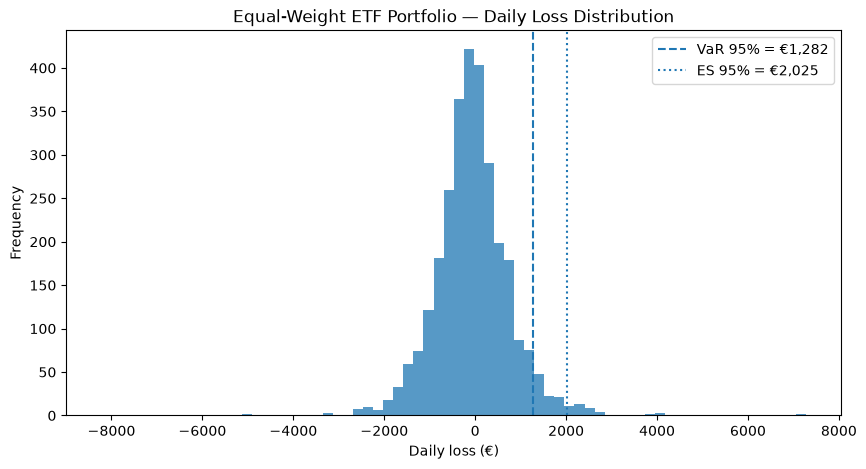

In [7]:
plt.figure(figsize=(10, 5))
plt.hist(portfolio_losses, bins=70, alpha=0.75)

var95 = historical_var(portfolio_losses.values, 0.95)
es95 = historical_es(portfolio_losses.values, 0.95)

plt.axvline(var95, linestyle="--", label=f"VaR 95% = €{var95:,.0f}")
plt.axvline(es95, linestyle=":", label=f"ES 95% = €{es95:,.0f}")

plt.title("Equal-Weight ETF Portfolio — Daily Loss Distribution")
plt.xlabel("Daily loss (€)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## 5. Parametric Gaussian VaR

If

$$
L\sim N(\mu_L,\sigma_L^2),
$$

then

$$
\boxed{
VaR_\alpha(L)
=
\mu_L
+
\sigma_L\Phi^{-1}(\alpha)
}.
$$

This is convenient but depends heavily on the Gaussian approximation.

In [8]:
loss_mu = portfolio_losses.mean()
loss_sigma = portfolio_losses.std(ddof=1)

gaussian_rows = []

for alpha in CONFIDENCE_LEVELS:
    z = stats.norm.ppf(alpha)

    var = loss_mu + loss_sigma * z
    es = loss_mu + loss_sigma * (
        stats.norm.pdf(z) / (1 - alpha)
    )

    gaussian_rows.append({
        "confidence": alpha,
        "Gaussian VaR": var,
        "Gaussian ES": es,
    })

gaussian_risk = pd.DataFrame(gaussian_rows).set_index("confidence")
gaussian_risk

,Gaussian VaR,Gaussian ES
confidence,,
0.950000,"1,399.770760","1,769.421997"
0.990000,"2,002.641782","2,302.413500"


## 6. Student-$t$ location-scale model

The lecture notes that VaR for a location-scale family

$$
L=\mu+\sigma X
$$

takes the form

$$
VaR_\alpha(L)
=
\mu+\sigma F_X^{-1}(\alpha).
$$

A Student-$t$ distribution is a natural example when tails are heavier than Normal.

We therefore fit a Student-$t$ distribution to the portfolio losses and compare its VaR with the Gaussian estimate.

In [9]:
df_t, loc_t, scale_t = stats.t.fit(portfolio_losses.values)

student_rows = []

for alpha in CONFIDENCE_LEVELS:
    var = stats.t.ppf(
        alpha,
        df=df_t,
        loc=loc_t,
        scale=scale_t,
    )

    student_rows.append({
        "confidence": alpha,
        "Student-t VaR": var,
    })

student_risk = pd.DataFrame(student_rows).set_index("confidence")

pd.Series({
    "fitted_df": df_t,
    "location": loc_t,
    "scale": scale_t,
}).to_frame("estimate")

,estimate
fitted_df,3.646410
location,-76.161831
scale,591.457581


In [10]:
risk_comparison = (
    historical_risk
    .join(gaussian_risk)
    .join(student_risk)
)

risk_comparison

,Historical VaR,Historical ES,Gaussian VaR,Gaussian ES,Student-t VaR
confidence,,,,,
0.950000,"1,282.206104","2,024.512208","1,399.770760","1,769.421997","1,220.699140"
0.990000,"2,332.420297","3,537.097283","2,002.641782","2,302.413500","2,263.579818"


## 7. Multi-day VaR and square-root-of-time scaling

Under an iid Normal approximation, volatility over $N$ days scales approximately as

$$
\sigma_N
=
\sqrt{N}\sigma_1.
$$

Therefore,

$$
VaR_{\alpha,N}
\approx
\sqrt{N}\,
VaR_{\alpha,1}
$$

when the mean term is negligible.

This rule is useful but should not be treated as exact when returns exhibit serial dependence, changing volatility, or fat tails.

In [11]:
horizons = [1, 5, 10, 20]

z95 = stats.norm.ppf(0.95)
z99 = stats.norm.ppf(0.99)

multi_day = pd.DataFrame(index=horizons)
multi_day.index.name = "holding_period_days"

multi_day["Gaussian VaR 95%"] = [
    loss_sigma * np.sqrt(h) * z95
    for h in horizons
]

multi_day["Gaussian VaR 99%"] = [
    loss_sigma * np.sqrt(h) * z99
    for h in horizons
]

multi_day

,Gaussian VaR 95%,Gaussian VaR 99%
holding_period_days,,
1,"1,455.088715","2,057.959737"
5,"3,253.677280","4,601.737868"
10,"4,601.394537","6,507.840103"
20,"6,507.354559","9,203.475736"


## 8. Monte Carlo VaR

For a more general portfolio, the lecture proposes:

1. identify risk factors $Z$,
2. generate scenarios $\Delta Z$,
3. revalue the portfolio under each scenario,
4. obtain a sample of $\Delta V$,
5. calculate VaR from the empirical loss distribution.

Here, the ETF returns themselves are treated as the risk-factor vector.

We simulate correlated returns from the estimated multivariate Gaussian distribution:

$$
R
\sim
N(\hat{\mu},\hat{\Sigma}).
$$

In [12]:
rng = np.random.default_rng(42)

N_SIM = 100_000
mu = returns.mean().values
cov = returns.cov().values

sim_returns = rng.multivariate_normal(
    mean=mu,
    cov=cov,
    size=N_SIM,
)

sim_portfolio_returns = sim_returns @ WEIGHTS.values
sim_losses = -PORTFOLIO_VALUE * sim_portfolio_returns

mc_rows = []

for alpha in CONFIDENCE_LEVELS:
    var = np.quantile(sim_losses, alpha)
    es = sim_losses[sim_losses >= var].mean()

    mc_rows.append({
        "confidence": alpha,
        "Monte Carlo VaR": var,
        "Monte Carlo ES": es,
    })

monte_carlo_risk = pd.DataFrame(mc_rows).set_index("confidence")
monte_carlo_risk

,Monte Carlo VaR,Monte Carlo ES
confidence,,
0.950000,"1,384.972056","1,757.784640"
0.990000,"1,995.337411","2,291.424908"


## 9. Stress testing

VaR is probability-based. Stress testing asks a different question:

> What happens to the portfolio under a severe but explicitly defined scenario?

The scenarios below are **hypothetical shocks**, not forecasts.

In [13]:
stress_scenarios = pd.DataFrame({
    "Semiconductor shock": {
        "SPY": -0.06,
        "SOXX": -0.15,
        "XLE": -0.03,
        "TLT": 0.02,
        "GLD": 0.01,
    },
    "Oil / energy shock": {
        "SPY": -0.03,
        "SOXX": -0.04,
        "XLE": -0.12,
        "TLT": 0.01,
        "GLD": 0.02,
    },
    "Rates-up shock": {
        "SPY": -0.04,
        "SOXX": -0.06,
        "XLE": 0.02,
        "TLT": -0.10,
        "GLD": -0.03,
    },
    "Broad risk-off": {
        "SPY": -0.10,
        "SOXX": -0.15,
        "XLE": -0.10,
        "TLT": 0.04,
        "GLD": 0.05,
    },
}).T[TICKERS]

stress_scenarios

,SPY,SOXX,XLE,TLT,GLD
Semiconductor shock,-0.060000,-0.150000,-0.030000,0.020000,0.010000
Oil / energy shock,-0.030000,-0.040000,-0.120000,0.010000,0.020000
Rates-up shock,-0.040000,-0.060000,0.020000,-0.100000,-0.030000
Broad risk-off,-0.100000,-0.150000,-0.100000,0.040000,0.050000


In [14]:
stress_results = stress_scenarios.copy()

stress_results["portfolio_return"] = (
    stress_scenarios.values @ WEIGHTS.values
)

stress_results["portfolio_PnL_EUR"] = (
    PORTFOLIO_VALUE * stress_results["portfolio_return"]
)

stress_results["loss_EUR"] = -stress_results["portfolio_PnL_EUR"]

stress_results

,SPY,SOXX,XLE,TLT,GLD,portfolio_return,portfolio_PnL_EUR,loss_EUR
Semiconductor shock,-0.060000,-0.150000,-0.030000,0.020000,0.010000,-0.042000,"-4,200.000000","4,200.000000"
Oil / energy shock,-0.030000,-0.040000,-0.120000,0.010000,0.020000,-0.032000,"-3,200.000000","3,200.000000"
Rates-up shock,-0.040000,-0.060000,0.020000,-0.100000,-0.030000,-0.042000,"-4,200.000000","4,200.000000"
Broad risk-off,-0.100000,-0.150000,-0.100000,0.040000,0.050000,-0.052000,"-5,200.000000","5,200.000000"


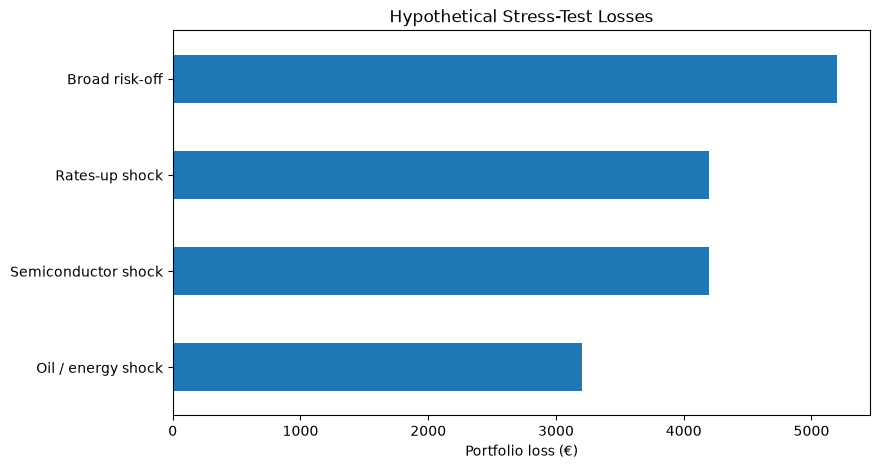

In [15]:
stress_results["loss_EUR"].sort_values().plot(
    kind="barh",
    figsize=(9, 5),
    title="Hypothetical Stress-Test Losses",
)
plt.xlabel("Portfolio loss (€)")
plt.show()

## 10. Why VaR is not the end of the story

The lecture gives an important counterexample using defaultable bonds.

Consider $N$ bonds with:

- issue price $100$,
- non-default return $b$,
- default probability $p$.

For one bond,

$$
L_i
=
\begin{cases}
100, & \text{default},\\
-100b, & \text{no default}.
\end{cases}
$$

Compare:

- **Portfolio A:** $N$ bonds from the same issuer,
- **Portfolio B:** $N$ bonds from independent issuers.

Economically, Portfolio B is diversified.

Yet VaR can rank the concentrated Portfolio A as *less risky* at a selected confidence level.

This demonstrates that VaR is not always subadditive.

In [16]:
N_BONDS = 100
b = 0.05
p = 0.02
alpha = 0.95

# Portfolio A: all 100 bonds share the same default event.
loss_A_no_default = -100 * N_BONDS * b
loss_A_default = 100 * N_BONDS

# At 95%, the no-default outcome already carries 98% probability.
var_A = loss_A_no_default

# Portfolio B: number of defaults is Binomial(N,p).
k = np.arange(N_BONDS + 1)
loss_B = 100 * (1 + b) * k - 100 * N_BONDS * b
cdf_B = binom.cdf(k, N_BONDS, p)

k_var = k[np.argmax(cdf_B >= alpha)]
var_B = loss_B[k_var]

pd.Series({
    "VaR95 concentrated_same_issuer": var_A,
    "VaR95 diversified_independent_issuers": var_B,
}).to_frame("loss")

,loss
VaR95 concentrated_same_issuer,-500.000000
VaR95 diversified_independent_issuers,25.000000


The result looks counterintuitive because the 95% quantile ignores what happens in the extreme tail beyond the threshold.

This is one reason to examine **Expected Shortfall** in addition to VaR.

## 11. Expected Shortfall / Average VaR

The lecture defines

$$
TVaR_\alpha(L)
=
E[L\mid L>VaR_\alpha(L)]
$$

and

$$
\boxed{
ES_\alpha(L)
=
AVaR_\alpha(L)
=
\frac{1}{1-\alpha}
\int_\alpha^1VaR_\gamma(L)\,d\gamma
}.
$$

For continuous loss distributions,

$$
TVaR_\alpha(L)
=
ES_\alpha(L)
=
AVaR_\alpha(L).
$$

Expected Shortfall answers the question:

> If we are already in the worst $1-\alpha$ fraction of outcomes, how large is the loss on average?

## 12. Convex risk measures

A convex risk measure $\rho$ satisfies, among other properties,

$$
\rho(
\lambda L_1+(1-\lambda)L_2
)
\le
\lambda\rho(L_1)
+
(1-\lambda)\rho(L_2),
\qquad
0\le\lambda\le1.
$$

This is economically appealing because diversification should not increase measured risk beyond the weighted combination of stand-alone risks.

The lecture identifies **AVaR / Expected Shortfall and TVaR** as convex risk measures, while the default example shows why VaR can fail this intuition.

## 13. Final risk dashboard table

The final comparison summarizes the portfolio's daily risk under multiple approaches.

In [17]:
final_risk_table = pd.DataFrame(index=["95%", "99%"])

final_risk_table["Historical VaR"] = [
    historical_risk.loc[0.95, "Historical VaR"],
    historical_risk.loc[0.99, "Historical VaR"],
]

final_risk_table["Historical ES"] = [
    historical_risk.loc[0.95, "Historical ES"],
    historical_risk.loc[0.99, "Historical ES"],
]

final_risk_table["Gaussian VaR"] = [
    gaussian_risk.loc[0.95, "Gaussian VaR"],
    gaussian_risk.loc[0.99, "Gaussian VaR"],
]

final_risk_table["Student-t VaR"] = [
    student_risk.loc[0.95, "Student-t VaR"],
    student_risk.loc[0.99, "Student-t VaR"],
]

final_risk_table["Monte Carlo VaR"] = [
    monte_carlo_risk.loc[0.95, "Monte Carlo VaR"],
    monte_carlo_risk.loc[0.99, "Monte Carlo VaR"],
]

final_risk_table["Monte Carlo ES"] = [
    monte_carlo_risk.loc[0.95, "Monte Carlo ES"],
    monte_carlo_risk.loc[0.99, "Monte Carlo ES"],
]

final_risk_table

,Historical VaR,Historical ES,Gaussian VaR,Student-t VaR,Monte Carlo VaR,Monte Carlo ES
95%,"1,282.206104","2,024.512208","1,399.770760","1,220.699140","1,384.972056","1,757.784640"
99%,"2,332.420297","3,537.097283","2,002.641782","2,263.579818","1,995.337411","2,291.424908"


## 14. Interpretation guide

Do not ask only:

> Which VaR number is largest?

Instead ask:

- How different are Historical, Gaussian, Student-$t$, and Monte Carlo estimates?
- Does the Normal model understate tail risk?
- How much protection does cross-asset diversification provide?
- Which hypothetical stress scenario causes the largest loss?
- How much larger is ES than VaR?
- Why can VaR fail in discontinuous/default-type loss distributions?
- Does the portfolio remain exposed to correlated market shocks even though it spans several asset classes?

These are the real risk-management questions.

## 15. Limitations

- Historical VaR assumes the observed sample is informative about future losses.
- Gaussian Monte Carlo assumes a stable mean/covariance structure and Normal risk factors.
- Student-$t$ is fitted only to the aggregate portfolio-loss distribution.
- The stress scenarios are illustrative and not probability forecasts.
- The equal-weight portfolio is chosen for transparency rather than optimality.
- ETF prices do not capture every underlying risk factor directly.
- Liquidity risk, option nonlinearities, credit migration, transaction costs and changing correlations are outside the current scope.
- Nothing in this notebook constitutes investment advice.